In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils import resample

import xgboost as xgb

from scipy.stats import randint, uniform

import os
import joblib

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/leonkriesmair/Repos/BigDataProject/.venv/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <54A1AE05-1E14-3DA2-A8D0-062134694298> /Users/leonkriesmair/Repos/BigDataProject/.venv/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/

XG Boositng Model. 
We use CATASTROPHIC as our dependent variable now. And we are using the transformed dataset with the vegetation dummies. 

In [23]:
df = pd.read_csv('../data/processed/FW_Veg_Rem_Combined_transformed.csv') 
df.head()

,index,latitude,longitude,Temp_pre_30,Temp_pre_15,Temp_pre_7,Wind_pre_30,Wind_pre_15,Wind_pre_7,Hum_pre_30,...,month_sin,month_cos,Vegetation_0,Vegetation_4,Vegetation_9,Vegetation_12,Vegetation_14,Vegetation_15,Vegetation_16,Vegetation
0,0,18.105072,-66.753044,24.480974,24.716923,24.902597,4.341807,3.492857,3.262092,78.216590,...,8.660254e-01,0.500000,False,False,False,True,False,False,False,Open Shrubland
1,1,35.038330,-87.610000,7.553433,7.010000,0.343529,2.709764,2.881707,1.976471,70.840000,...,-2.449294e-16,1.000000,False,False,False,False,False,True,False,Polar Desert/Rock/Ice
2,2,34.947800,-88.722500,4.971930,5.782766,5.558750,3.364499,2.923830,2.695833,75.531629,...,8.660254e-01,0.500000,False,False,False,False,False,False,True,Secondary Tropical Evergreen Broadleaf Forest
3,3,39.641400,-119.308300,16.275967,18.996181,18.142564,4.054982,3.398329,3.671282,44.778429,...,1.224647e-16,-1.000000,True,False,False,False,False,False,False,Unknown
4,4,31.316978,-83.393649,14.877341,16.409326,17.175319,2.000214,1.727202,1.590696,79.896679,...,5.000000e-01,0.866025,False,False,False,True,False,False,False,Open Shrubland


In [ ]:
X = df.drop(['catastrophic', 'Vegetation', 'index'], axis=1)
y = df['catastrophic']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify = y
)

xgb_model = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred) 
class_report = classification_report(y_test, y_pred)  
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:", class_report)

Accuracy: 0.7593388873958613
Confusion Matrix:
 [[4735  130]
 [1661  916]]
Classification Report:               precision    recall  f1-score   support

           0       0.74      0.97      0.84      4865
           1       0.88      0.36      0.51      2577

    accuracy                           0.76      7442
   macro avg       0.81      0.66      0.67      7442
weighted avg       0.79      0.76      0.72      7442



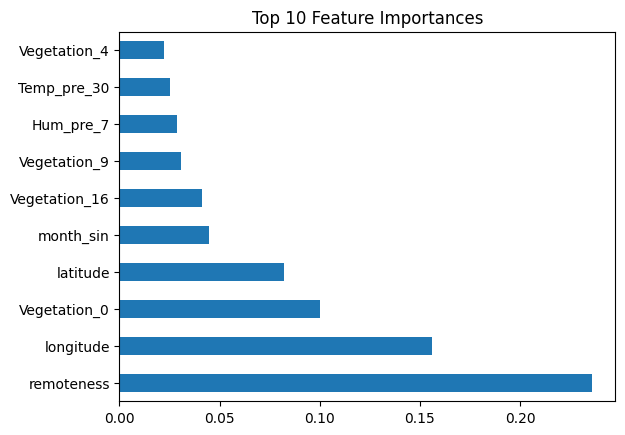

In [ ]:
# Feature Importance
feature_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.show()

Using Categorical Vegetation Variable instead of dummies 

In [26]:
df = pd.read_csv('../data/processed/FW_Veg_Rem_Combined_transformed.csv') 
dummy_cols = [col for col in df.columns if col.startswith('Vegetation_')]
df = df.drop(columns=dummy_cols)
df.head()

,index,latitude,longitude,Temp_pre_30,Temp_pre_15,Temp_pre_7,Wind_pre_30,Wind_pre_15,Wind_pre_7,Hum_pre_30,Hum_pre_15,Hum_pre_7,Prec_pre_30,Prec_pre_15,Prec_pre_7,remoteness,catastrophic,month_sin,month_cos,Vegetation
0,0,18.105072,-66.753044,24.480974,24.716923,24.902597,4.341807,3.492857,3.262092,78.216590,76.793750,76.381579,0.0,0.0,0.0,0.017923,1,8.660254e-01,0.500000,Open Shrubland
1,1,35.038330,-87.610000,7.553433,7.010000,0.343529,2.709764,2.881707,1.976471,70.840000,65.858911,55.505882,59.8,8.4,0.0,0.184355,0,-2.449294e-16,1.000000,Polar Desert/Rock/Ice
2,2,34.947800,-88.722500,4.971930,5.782766,5.558750,3.364499,2.923830,2.695833,75.531629,75.868613,76.812834,168.8,42.2,18.1,0.194544,1,8.660254e-01,0.500000,Secondary Tropical Evergreen Broadleaf Forest
3,3,39.641400,-119.308300,16.275967,18.996181,18.142564,4.054982,3.398329,3.671282,44.778429,37.140811,35.353846,10.4,7.2,0.0,0.487447,0,1.224647e-16,-1.000000,Unknown
4,4,31.316978,-83.393649,14.877341,16.409326,17.175319,2.000214,1.727202,1.590696,79.896679,73.431818,70.199388,26.0,0.0,0.0,0.148904,0,5.000000e-01,0.866025,Open Shrubland


In [28]:
X = df.drop(['catastrophic','index'], axis=1)
y = df['catastrophic']




X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify = y
)

# Converting string columns to pandas 'category' type
X_train['Vegetation'] = X_train['Vegetation'].astype('category')
X_test['Vegetation'] = X_test['Vegetation'].astype('category')


xgb_model2 = xgb.XGBClassifier(
    n_estimators=75, 
    learning_rate=0.1, 
    max_depth=6, 
    random_state=42,
    colsample_bytree=0.5,
    enable_categorical=True,  
    tree_method="hist"        # Required for categorical support
)
xgb_model2.fit(X_train, y_train)
y_pred2 = xgb_model2.predict(X_test)
accuracy = accuracy_score(y_test, y_pred2)
conf_matrix = confusion_matrix(y_test, y_pred2)  
class_report = classification_report(y_test, y_pred2)  
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:", class_report)

Accuracy: 0.7621607094866971
Confusion Matrix:
 [[4734  131]
 [1639  938]]
Classification Report:               precision    recall  f1-score   support

           0       0.74      0.97      0.84      4865
           1       0.88      0.36      0.51      2577

    accuracy                           0.76      7442
   macro avg       0.81      0.67      0.68      7442
weighted avg       0.79      0.76      0.73      7442



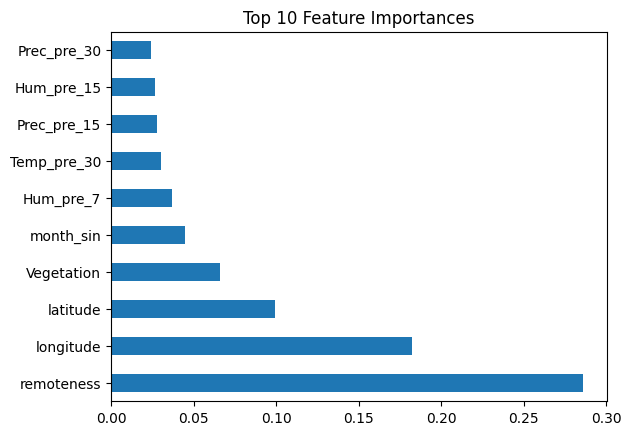

In [ ]:
# Feature Importance
feature_importances2 = pd.Series(xgb_model2.feature_importances_, index=X_train.columns)
feature_importances2.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.show()

TRYING OUT HISTGRADIENTBOOSTING, ALSO A VERY GOOD OPTION TO USE

In [ ]:
# Train HistGradientBoosting
hist_gb_model = HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=6,
    learning_rate=0.05
)
hist_gb_model.fit(X_train, y_train)

# Evaluation
y_pred_hist = hist_gb_model.predict(X_test)
y_pred_proba = hist_gb_model.predict_proba(X_test)[:, 1]

print("HistGradientBoosting AUC:", roc_auc_score(y_test, y_pred_proba))

HistGradientBoosting AUC: 0.7732932762388127


NOW WE WANT TO FOCUS MORE ON RECALL RATHER THAN ACCURACY, SO I INCORPORATE IT IN THE GRID SEARCH


STEP 1: RANDOMIZED GRID SEARCH FOR HYPERPARAMETERS, FOCUSING ON RECALL AS MY SCORING PARAMETER


In [ ]:
# Define param distributions for RSCV
param_dist = {
    'n_estimators': randint(100, 300),     
    'max_depth': [4, 5 ,6, 8, 10],
    "learning_rate": [0.05, 0.1],
    "colsample_bytree": [0.5, 0.75],
    'min_child_weight': [4, 5, 6], # after a lot of tries the opimal was 5, so now I use a different range (before randit(1, 10))
    'gamma': uniform(4.5 , 3), # increasing the gamma does significantly improve recall rate with slight reduction in accuracy
    'scale_pos_weight': [1.8 , 2, 2.2] # scaling the number of catastrophic fires to normal fires can be useful in ballancing predictions, I will use 1 (neutral), 1.8 (appr. the ratio) and 2
}

XGBoost = xgb.XGBClassifier()

# Randomized Search setup
random_search = RandomizedSearchCV(
    estimator=XGBoost,
    param_distributions=param_dist,
    n_iter=100,                 # relative high number due to fast processing from XGBoost
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='recall',  # Focus on Recall instead of accuracy
    random_state=42
)

random_search.fit(X_train, y_train)
print(random_search.best_params_)
print(random_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END colsample_bytree=0.5, gamma=6.889628960580699, learning_rate=0.05, max_depth=6, min_child_weight=4, n_estimators=120, scale_pos_weight=2.2; total time=   0.3s
[CV] END colsample_bytree=0.5, gamma=6.889628960580699, learning_rate=0.05, max_depth=6, min_child_weight=4, n_estimators=120, scale_pos_weight=2.2; total time=   0.3s
[CV] END colsample_bytree=0.5, gamma=6.889628960580699, learning_rate=0.05, max_depth=6, min_child_weight=4, n_estimators=120, scale_pos_weight=2.2; total time=   0.4s
[CV] END colsample_bytree=0.5, gamma=6.889628960580699, learning_rate=0.05, max_depth=6, min_child_weight=4, n_estimators=120, scale_pos_weight=2.2; total time=   0.4s
[CV] END colsample_bytree=0.5, gamma=6.889628960580699, learning_rate=0.05, max_depth=6, min_child_weight=4, n_estimators=120, scale_pos_weight=2.2; total time=   0.3s
[CV] END colsample_bytree=0.75, gamma=4.967983561008608, learning_rate=0.05, max_depth=6, min_chi

Best Model according RSCV

In [61]:
best_model = random_search.best_estimator_
y_pred_recall = best_model.predict(X_test)
accuracy_recall = accuracy_score(y_test, y_pred_recall)
conf_matrix_recall = confusion_matrix(y_test, y_pred_recall)  
class_report_recall = classification_report(y_test, y_pred_recall)  

print("Accuracy:", accuracy_recall)
print("Confusion Matrix:\n", conf_matrix_recall)
print("Classification Report:", class_report_recall)

Accuracy: 0.6857027680730986
Confusion Matrix:
 [[3297 1568]
 [ 771 1806]]
Classification Report:               precision    recall  f1-score   support

           0       0.81      0.68      0.74      4865
           1       0.54      0.70      0.61      2577

    accuracy                           0.69      7442
   macro avg       0.67      0.69      0.67      7442
weighted avg       0.72      0.69      0.69      7442



STEP 2: GRIDSEARCH IN THE OPTIMAL AREA, after updating the parameter grid

In [68]:
# Using RandomizedSearch to first find area of interesting parameters
# and then using GridSearch to find the best parameters in that area

xgb_model3 = xgb.XGBClassifier(
    n_estimators=200, # also letting n_estimators fixed
    learning_rate=0.05, 
    max_depth=5,
    min_child_weight=4, # This and colsample_bytree are fixed bc for grid seach other variables are more imporant 
    random_state=42,
    colsample_bytree=0.5,
    scale_pos_weight=2, # This is set to 2, due to number of catastrophic to non-catastrophic fires
    enable_categorical=True,  
    tree_method="hist"        
)

best_params = random_search.best_params_
param_grid_fine = {  
    'max_depth': [best_params['max_depth'] - 1, best_params['max_depth'], best_params['max_depth'] + 1],
    'learning_rate': [best_params['learning_rate'] - 0.02, best_params['learning_rate'], best_params['learning_rate'] + 0.02],
    'gamma': [best_params['gamma'] - 0.3, best_params['gamma'], best_params['gamma'] + 0.3],
    'n_estimators': [best_params['n_estimators']],
    'min_child_weight': [best_params['min_child_weight']],
    'colsample_bytree': [best_params['colsample_bytree']],
    'scale_pos_weight': [best_params['scale_pos_weight']],
}

grid_search_first = GridSearchCV(
    estimator=xgb_model3,
    param_grid=param_grid_fine,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=2
)
grid_search_first.fit(X_train, y_train)

print(grid_search_first.best_params_)
print(grid_search_first.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END colsample_bytree=0.5, gamma=7.115136286167311, learning_rate=0.030000000000000002, max_depth=3, min_child_weight=4, n_estimators=241, scale_pos_weight=2.2; total time=   0.3s
[CV] END colsample_bytree=0.5, gamma=7.115136286167311, learning_rate=0.030000000000000002, max_depth=3, min_child_weight=4, n_estimators=241, scale_pos_weight=2.2; total time=   0.3s
[CV] END colsample_bytree=0.5, gamma=7.115136286167311, learning_rate=0.030000000000000002, max_depth=3, min_child_weight=4, n_estimators=241, scale_pos_weight=2.2; total time=   0.3s
[CV] END colsample_bytree=0.5, gamma=7.115136286167311, learning_rate=0.030000000000000002, max_depth=3, min_child_weight=4, n_estimators=241, scale_pos_weight=2.2; total time=   0.3s
[CV] END colsample_bytree=0.5, gamma=7.115136286167311, learning_rate=0.030000000000000002, max_depth=4, min_child_weight=4, n_estimators=241, scale_pos_weight=2.2; total time=   0.3s
[CV] END colsample

In [69]:
print(grid_search_first.best_params_ , random_search.best_params_)

{'colsample_bytree': 0.5, 'gamma': np.float64(7.115136286167311), 'learning_rate': 0.07, 'max_depth': 4, 'min_child_weight': 4, 'n_estimators': 241, 'scale_pos_weight': 2.2} {'colsample_bytree': 0.5, 'gamma': np.float64(7.415136286167311), 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 4, 'n_estimators': 241, 'scale_pos_weight': 2.2}


STEP 3: IMPLEMENTATION OF OPTIMAL HYPERPARAMETERS IN XGBOOST MODEL

In [70]:
xgb_model_final = grid_search_first.best_estimator_
xgb_model_final.fit(X_train, y_train)

y_pred_final = xgb_model_final.predict(X_test)
accuracy_final = accuracy_score(y_test, y_pred_final)
conf_matrix_final = confusion_matrix(y_test, y_pred_final)  
class_report_final = classification_report(y_test, y_pred_final)  

print("Accuracy:", accuracy_final)
print("Confusion Matrix:\n", conf_matrix_final)
print("Classification Report:", class_report_final)

Accuracy: 0.6861058855146466
Confusion Matrix:
 [[3303 1562]
 [ 774 1803]]
Classification Report:               precision    recall  f1-score   support

           0       0.81      0.68      0.74      4865
           1       0.54      0.70      0.61      2577

    accuracy                           0.69      7442
   macro avg       0.67      0.69      0.67      7442
weighted avg       0.72      0.69      0.69      7442



Plot for Confusion Matrix and Feature Importance of the final Boosting Model

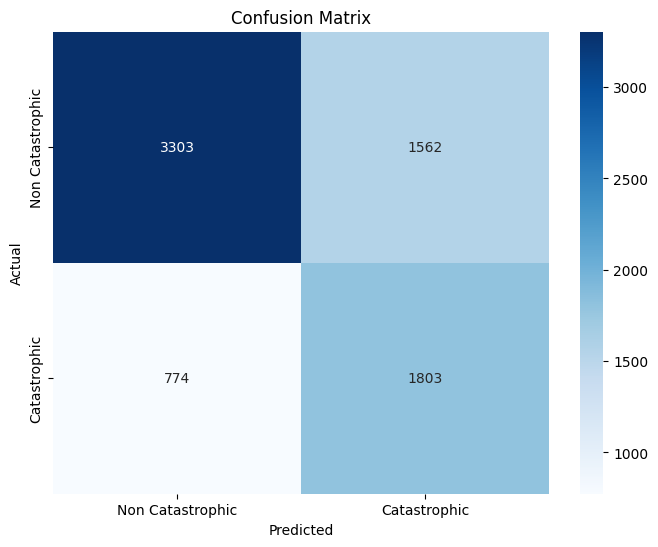

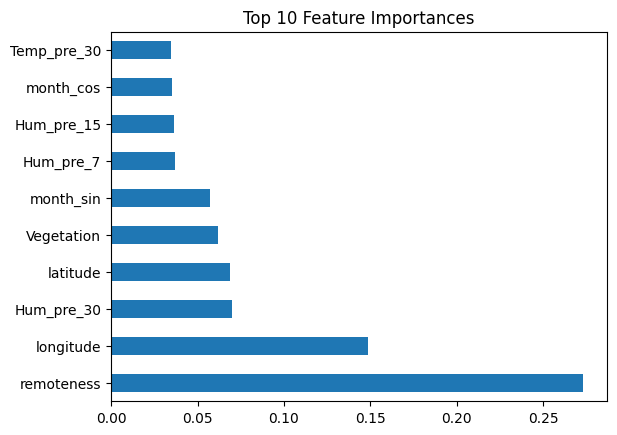

In [ ]:
# Plotting Confusion Matrix with labels
class_names = ['Non Catastrophic','Catastrophic']
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Importance
feature_importances_final = pd.Series(xgb_model2.feature_importances_, index=X_train.columns)
feature_importances_final.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.show()

In [ ]:
# Resample 80% of the training data
X_small, y_small = resample(X_train, y_train, n_samples=int(0.8 * len(X_train)), random_state=42)

# Rebuild XGBoost model with the same best hyperparameters
xgb_model_small = xgb.XGBClassifier(**xgb_model_final.get_params())
xgb_model_small.fit(X_small, y_small)

# Evaluate on the same test set
y_pred_small = xgb_model_small.predict(X_test)
print("Accuracy with reduced training set:", accuracy_score(y_test, y_pred_small))


Accuracy with reduced training set: 0.6920182746573502


In [ ]:


# Perform 5-fold cross-validation
cv_scores = cross_val_score(
    xgb_model_final, X_train, y_train,
    cv=5,
    scoring='accuracy',  # or 'recall', 'f1', depending on your goal
    n_jobs=-1
)

print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Cross-Validation Accuracy Scores: [0.68071884 0.68452881 0.66403494 0.67277003 0.673106  ]
Mean CV Accuracy: 0.6750317245474727


### Exporting the Models

In [ ]:
models_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "models"))

joblib.dump(xgb_model_final, os.path.join(models_dir, "XGBoost_model.joblib"))